In [10]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import matplotlib.pyplot as plt
from DataLoader.data_loader import DataLoader
from ClusteringAlgorithms.clustering_module import CLARANS, ROCK

In [5]:
n_samples = 300
loader = DataLoader(n_samples=n_samples)

### Toy Datasets from scikit-learn

In [14]:
datasets = {
    "Blobs": loader.get_blobs(),
    "Circles": loader.get_circles(factor=0.5, noise=0.05),
    "Moons": loader.get_moons(noise=0.05)
}

In [8]:
params_clarans = {'k': 2, 'numlocal': 2, 'maxneighbor': 3}
params_rock = {'k': 2, 'theta': 0.4}

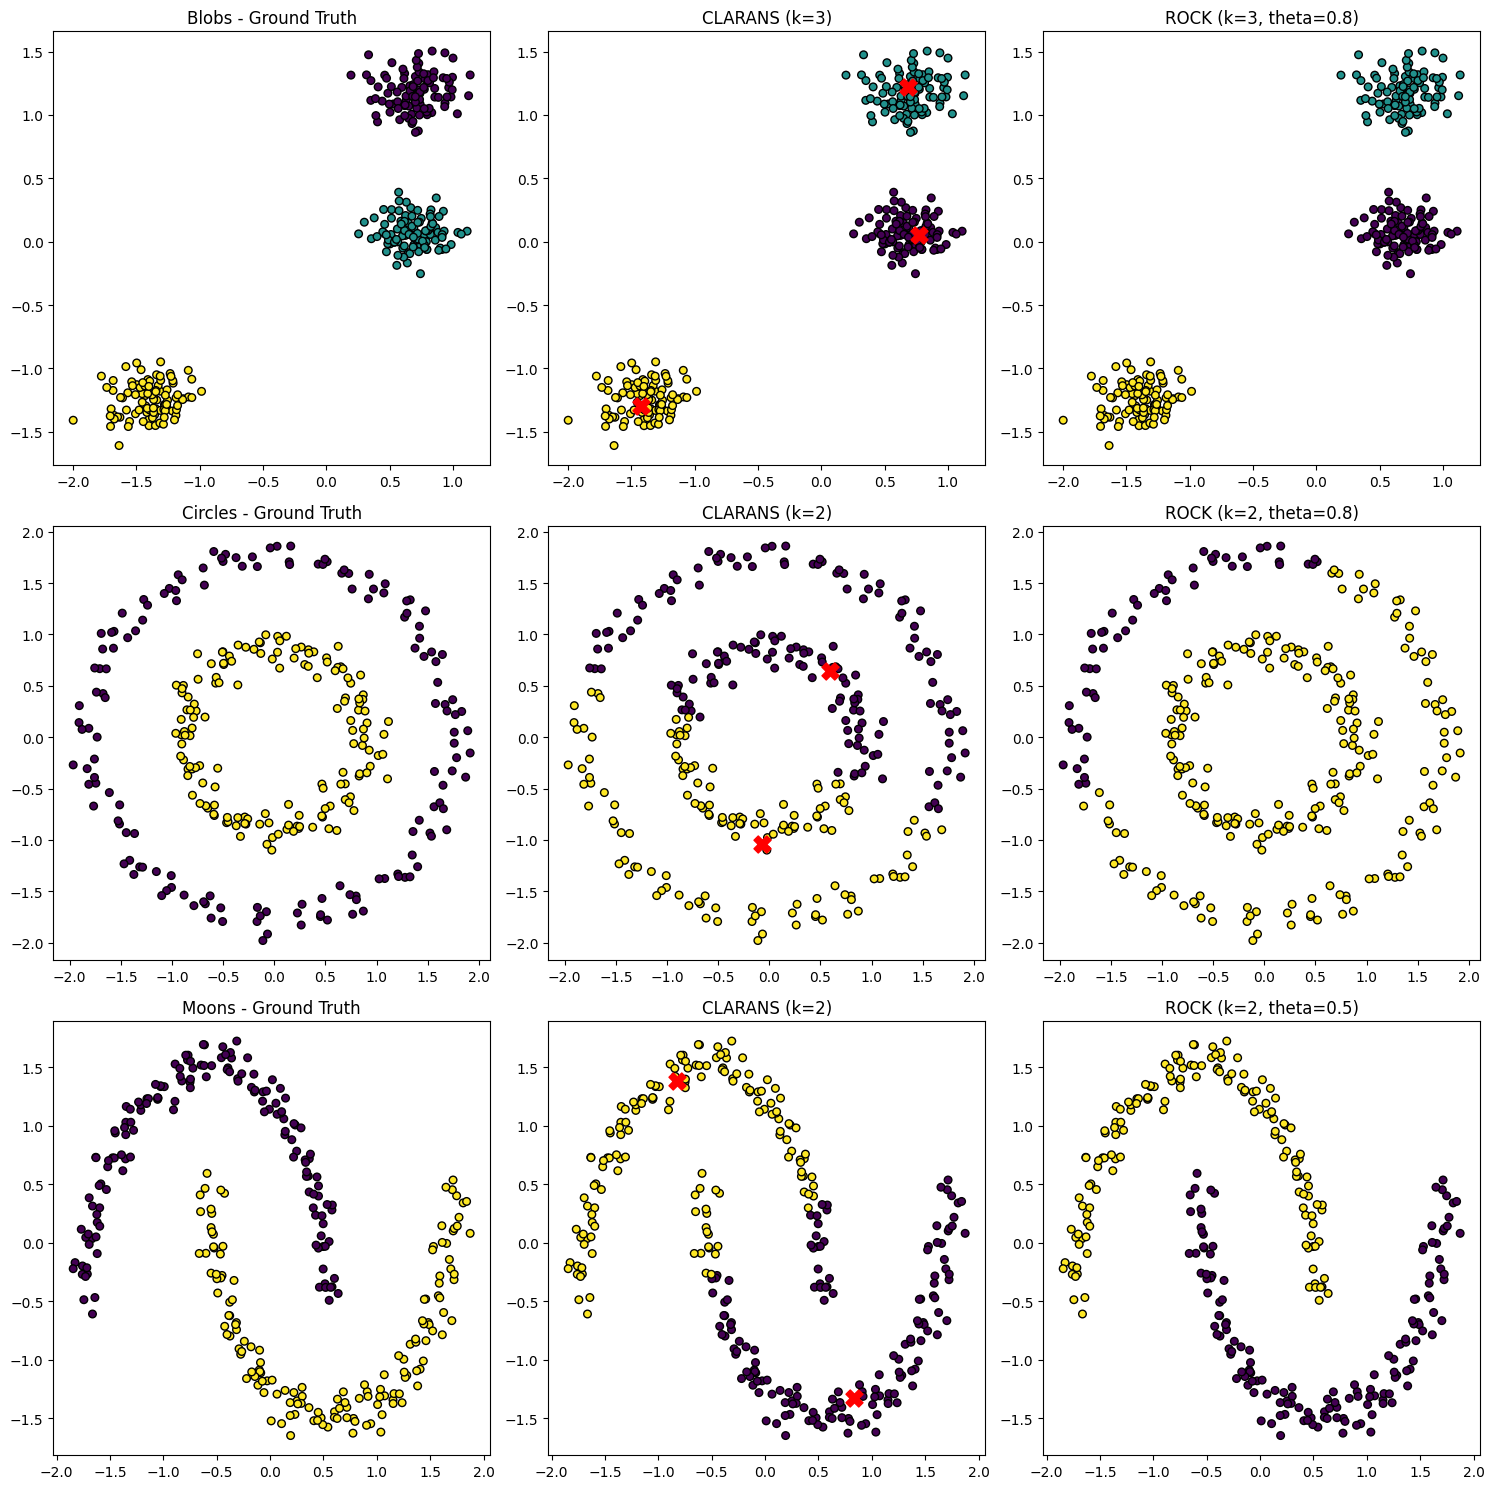

In [15]:
fig, axes = plt.subplots(len(datasets), 3, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)

for idx, (name, (X, y_true)) in enumerate(datasets.items()):
    
    # For Blobs K=3, for others K=2
    k_clusters = 3 if name == "Blobs" else 2
    
    # Original Data
    axes[idx, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 0].set_title(f"{name} - Ground Truth")
    
    # CLARANS
    clarans = CLARANS(k=k_clusters, numlocal=3, maxneighbor=5)
    clarans.fit(X)
    axes[idx, 1].scatter(X[:, 0], X[:, 1], c=clarans.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 1].scatter(clarans.medoids_vectors_[:, 0], clarans.medoids_vectors_[:, 1], 
                         c='red', marker='X', s=150, label='Medoids')
    axes[idx, 1].set_title(f"CLARANS (k={k_clusters})")
    
    # ROCK
    # We empirically choose theta for ROCK based on the dataset characteristics (normalized with a scaler)
    theta_val = 0.5 if name == "Moons" else 0.8
    rock = ROCK(k=k_clusters, theta=theta_val)
    rock.fit(X)
    axes[idx, 2].scatter(X[:, 0], X[:, 1], c=rock.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 2].set_title(f"ROCK (k={k_clusters}, theta={theta_val})")

plt.tight_layout()
plt.show()

# METRICS

In [25]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, # External
    silhouette_score, calinski_harabasz_score, davies_bouldin_score # Internal
)
import numpy as np
import pandas as pd

In [26]:
n_samples = 300
loader = DataLoader(n_samples=n_samples)
datasets = {
    "Blobs": loader.get_blobs(),
    "Circles": loader.get_circles(factor=0.5, noise=0.05),
    "Moons": loader.get_moons(noise=0.05)
}

In [29]:
evaluation_results = []

def evaluate_clustering(X, y_true, y_pred, algo_name, dataset_name):
    """Support function to compute metrics with cluster count checks."""
    n_clusters = len(np.unique(y_pred))
    
    # External metrics (always computable since we have y_true)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    
    # Internal metrics (require at least 2 clusters and fewer than n_samples)
    if 1 < n_clusters < len(X):
        sil = silhouette_score(X, y_pred)
        ch = calinski_harabasz_score(X, y_pred)
        db = davies_bouldin_score(X, y_pred)
    else:
        sil, ch, db = None, None, None
        
    return {
        "Dataset": dataset_name,
        "Algorithm": algo_name,
        "Clusters Found": n_clusters,
        "ARI (Ext)": round(ari, 3),
        "NMI (Ext)": round(nmi, 3),
        "Silhouette (Int)": round(sil, 3) if sil else "N/A",
        "Calinski-Harabasz (Int)": round(ch, 1) if ch else "N/A",
        "Davies-Bouldin (Int)": round(db, 3) if db else "N/A"
    }

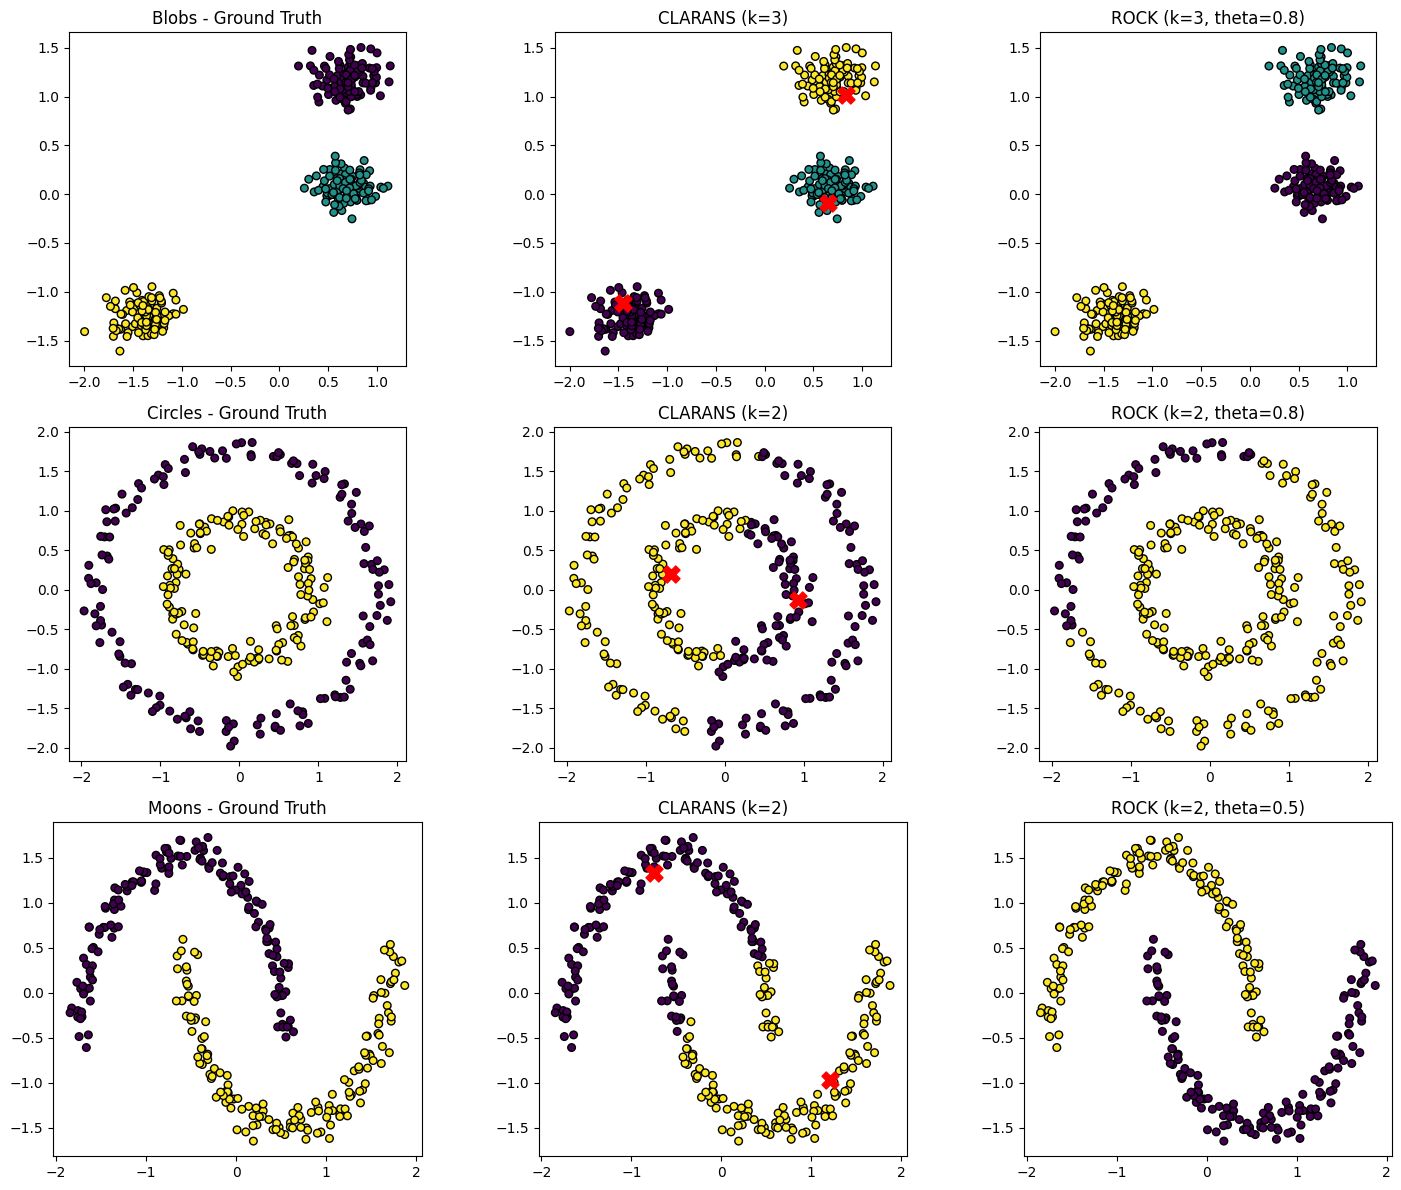

Clusters Found  ARI (Ext)  NMI (Ext)  Silhouette (Int)  \
Dataset Algorithm                                                           
Blobs   CLARANS                 3      1.000      1.000             0.801   
        ROCK                    3      1.000      1.000             0.801   
Circles CLARANS                 2     -0.002      0.001             0.348   
        ROCK                    2      0.123      0.244             0.267   
Moons   CLARANS                 2      0.488      0.390             0.496   
        ROCK                    2      1.000      1.000             0.386   

                   Calinski-Harabasz (Int)  Davies-Bouldin (Int)  
Dataset Algorithm                                                 
Blobs   CLARANS                     6063.5                 0.281  
        ROCK                        6063.5                 0.281  
Circles CLARANS                      170.9                 1.188  
        ROCK                          88.6                 1.221  
Moons   CLARANS                      418.2                 0.807  
        ROCK                         259.6                 1.021

In [30]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

for idx, (name, (X, y_true)) in enumerate(datasets.items()):
    k_clusters = 3 if name == "Blobs" else 2
    
    # Ground Truth Plot
    axes[idx, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 0].set_title(f"{name} - Ground Truth")
    axes[idx, 0].set_aspect("equal", "box")
    
    # CLARANS
    clarans = CLARANS(k=k_clusters, numlocal=3, maxneighbor=5)
    clarans.fit(X)
    axes[idx, 1].scatter(X[:, 0], X[:, 1], c=clarans.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 1].scatter(clarans.medoids_vectors_[:, 0], clarans.medoids_vectors_[:, 1], 
                         c='red', marker='X', s=150, label='Medoids')
    axes[idx, 1].set_title(f"CLARANS (k={k_clusters})")
    axes[idx, 1].set_aspect("equal", "box")
    
    # Collecting metrics for CLARANS
    evaluation_results.append(evaluate_clustering(X, y_true, clarans.labels_, "CLARANS", name))
    
    # ROCK
    theta_val = 0.5 if name == "Moons" else 0.8
    rock = ROCK(k=k_clusters, theta=theta_val)
    rock.fit(X)
    axes[idx, 2].scatter(X[:, 0], X[:, 1], c=rock.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 2].set_title(f"ROCK (k={k_clusters}, theta={theta_val})")
    axes[idx, 2].set_aspect("equal", "box")
    
    # Collecting metrics for ROCK
    evaluation_results.append(evaluate_clustering(X, y_true, rock.labels_, "ROCK", name))

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(evaluation_results)
df_results.set_index(["Dataset", "Algorithm"], inplace=True)
display(df_results)

### Blobs Dataset (Classic Spherical Structures)

* **Winners:** Tie (both algorithms performed flawlessly).
* **Analysis:** "Blobs" structures are well-separated point clouds. External metrics of **1.000** indicate a perfect match with the ground truth labels.
* **Why does CLARANS work here?** CLARANS minimizes a global cost function based on the distance of points to their representatives (medoids). This function can be described as:

$$Cost = \sum_{i=1}^{n} \min_{m \in M} d(x_i, m)$$

where $M$ is the set of medoids, and $d(x_i, m)$ is the Euclidean distance. The Blobs dataset naturally favors such minimization.

### Moons Dataset (Non-linear Clusters)

* **Winner:** ROCK.
* **Analysis:** ROCK perfectly reconstructs the clusters (ARI = **1.000**), while CLARANS splits the "moons" with a straight line (ARI = **0.488**).
* **Why does ROCK win?** This algorithm does not rely on absolute distance to a center, but on the concept of "links" (common neighbors). The function evaluating the goodness of merging two clusters $C_i$ and $C_j$ is defined by the formula:

$$g(C_i, C_j) = \frac{link(C_i, C_j)}{(n_i + n_j)^{1+2f(\alpha)} - n_i^{1+2f(\alpha)} - n_j^{1+2f(\alpha)}}$$

Because of this, the algorithm can "traverse" along dense neighborhood paths following the non-linear curves of the moons, ignoring the fact that the ends of the same moon are far apart in a Euclidean sense.

### Circles Dataset (Concentric Circles)

* **Winners:** None (both algorithms fail).
* **Analysis:** CLARANS performs worse than random guessing (ARI = **-0.002**). ROCK attempts to cluster but also fails (ARI = **0.123**).
* **Why did ROCK fail?** The key here is the parameter $\theta$, which defines the binary adjacency matrix $A$:

$$A_{ij} = \begin{cases} 1 & \text{if } d(x_i, x_j) \le \theta \\ 0 & \text{otherwise} \end{cases}$$

In the `Circles` dataset, the distance between the inner and outer circles is relatively small. The $\theta$ value used in the script was too large, causing the clusters to share common neighbors, which led to a "short-circuit" and incorrect merging.

---

### The Mathematical Paradox of Internal Metrics

The results reveal a critical flaw in internal evaluation measures. On the **Moons** dataset, the ROCK algorithm clustered the data perfectly, while CLARANS performed terribly. Despite this, the internal metric **Silhouette Score ($s$) rated the incorrect CLARANS result higher (0.496) than the perfect ROCK result (0.386)**.

**Why does this happen?**
For any point $i$, the Silhouette coefficient is calculated as:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

Where:
* $a(i)$ is the mean distance between a point $i$ and all other points in **its own** cluster.
* $b(i)$ is the mean distance between a point $i$ and the points in the **nearest neighboring** cluster.

Writing $a(i)$ formally:

$$a(i) = \frac{1}{|C_I| - 1} \sum_{j \in C_I, i \neq j} d(x_i, x_j)$$

**Conclusion:** Because $a(i)$ increases when a cluster has an irregular, elongated shape (like a moon), the fraction $s(i)$ inevitably decreases. CLARANS, on the other hand, sliced the moons into two compact, roughly circular chunks. For circles, the distance $a(i)$ is very small, so the equation $s(i)$ artificially promotes this incorrect division. 

This is excellent proof that for complex data topologies, optimizing for internal metrics (like Silhouette or Calinski-Harabasz) can lead to selecting a **worse** model. That is exactly why the Adjusted Rand Index (adjusted for the expected value of random partitions $E[RI]$) remains the most reliable evaluation method, provided we have Ground Truth labels:

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$